<a href="https://colab.research.google.com/github/SIDDH4RTH245/lstm-time-series-forecasting/blob/main/notebooks/05_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 5: Evaluation + Future Forecast

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [6]:
df = pd.read_csv("/content/airline-passengers.csv")

df.columns = ["Month", "Passengers"]

data = df["Passengers"].values.reshape(-1,1)

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [8]:
model = tf.keras.models.load_model(
    "/content/lstm_model.h5",
    custom_objects={'mse': tf.keras.losses.MeanSquaredError()}
)

In [9]:
last_sequence = data_scaled[-10:]
future_preds = []

for _ in range(12):  # next 12 months
    pred = model.predict(last_sequence.reshape(1,10,1))
    future_preds.append(pred[0][0])

    last_sequence = np.append(last_sequence[1:], pred, axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [10]:
future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))

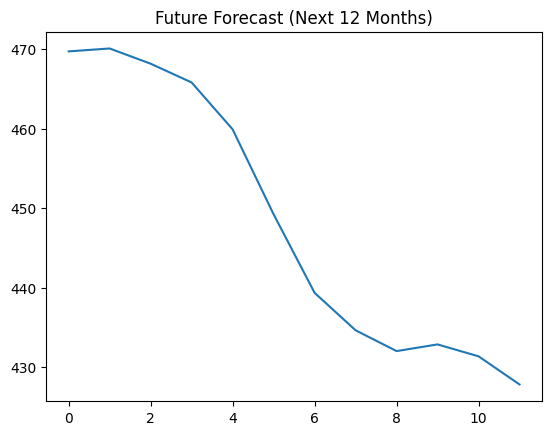

In [11]:
plt.plot(future_preds)
plt.title("Future Forecast (Next 12 Months)")
plt.show()